# Data Science Workflow: Optimized AAPL Stock Prediction
This notebook demonstrates an advanced optimization workflow: Using `StandardScaler`, enriched technical features (Bollinger Bands, VROC), and a hyperparameter tuning loop to identify the best lookback window.

## 1. Setup & Imports

In [26]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Dense, Dropout, Bidirectional,
    Input, Flatten, Permute, Multiply, RepeatVector, Activation, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 2. Acquire Data

In [27]:
tickers = ['AAPL', '^TNX', '^VIX']
data = yf.download(tickers, start='2015-01-01', end='2024-01-01')

df = pd.DataFrame()
# Reconstruct AAPL columns
df['Open'] = data['Open']['AAPL']
df['High'] = data['High']['AAPL']
df['Low'] = data['Low']['AAPL']
df['Close'] = data['Close']['AAPL']
df['Volume'] = data['Volume']['AAPL']

# Extract TNX and VIX columns
df['TNX_Close'] = data['Close']['^TNX']
df['VIX_Close'] = data['Close']['^VIX']

df.dropna(inplace=True)
df.head()

[*********************100%***********************]  3 of 3 completed


,Open,High,Low,Close,Volume,TNX_Close,VIX_Close
Date,,,,,,,
2015-01-02,24.671157,24.682231,23.776359,24.214899,212818400,2.123,17.790001
2015-01-05,23.984555,24.064289,23.346680,23.532726,257142000,2.039,19.920000
2015-01-06,23.596954,23.794075,23.173918,23.534939,263188400,1.963,21.120001
2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600,1.954,19.309999
2015-01-08,24.192743,24.839477,24.075355,24.781891,237458000,2.016,17.010000


## 3. Advanced Feature Engineering
We are adding:
- **Bollinger Bands**: To capture volatility.
- **VROC (Volume Rate of Change)**: To capture volume momentum.
- **Price/SMA Ratios**: To normalize the trend position.
- **Percentage Returns**: As the stationary target.

In [28]:
# 1. Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 2. Bollinger Bands
std_20 = df['Close'].rolling(window=20).std()
df['Upper_BB'] = df['SMA_20'] + (std_20 * 2)
df['Lower_BB'] = df['SMA_20'] - (std_20 * 2)

# 3. Volume Rate of Change (VROC)
df['VROC'] = df['Volume'].pct_change(periods=10)

# 4. MACD & RSI
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 5. Price-to-SMA Ratio
df['Price_SMA_Ratio'] = df['Close'] / df['SMA_20']

# 6. Rolling VWAP (20-day window)
typical_price = (df['High'] + df['Low'] + df['Close']) / 3
df['VWAP'] = (typical_price * df['Volume']).rolling(20).sum() / df['Volume'].rolling(20).sum()

# 7. VWAP Ratio (normalized distance from VWAP)
df['VWAP_Ratio'] = df['Close'] / df['VWAP']

# 8. Target Variable & Macro Indicators
df['Return'] = df['Close'].pct_change()
df['TNX_Return'] = df['TNX_Close'].pct_change()
df['VIX_Return'] = df['VIX_Close'].pct_change()

df.dropna(inplace=True)
df.tail()

,Open,High,Low,Close,Volume,TNX_Close,VIX_Close,SMA_20,SMA_50,Upper_BB,...,VROC,MACD,Signal_Line,RSI,Price_SMA_Ratio,VWAP,VWAP_Ratio,Return,TNX_Return,VIX_Return
Date,,,,,,,,,,,,,,,,,,,,,
2023-12-22,193.173193,193.400839,190.985924,191.609451,37149600,3.901,13.03,191.677266,183.401255,197.439432,...,-0.304398,2.630678,3.232230,59.246039,0.999646,192.064390,0.997631,-0.005548,0.001798,-0.045421
2023-12-26,191.619364,191.896484,190.847385,191.065125,28919300,3.886,12.99,191.838590,183.686993,197.322179,...,-0.525475,2.302595,3.046303,49.031924,0.995968,192.203372,0.994078,-0.002841,-0.003845,-0.003070
2023-12-27,190.510906,191.510516,189.125291,191.164108,48087700,3.789,12.43,191.974677,183.977281,197.233886,...,-0.087466,2.027205,2.842483,52.291557,0.995778,192.269619,0.994250,0.000518,-0.024961,-0.043110
2023-12-28,192.143946,192.658604,191.183918,191.589706,34049900,3.850,12.47,192.183013,184.307116,196.994047,...,-0.516366,1.822293,2.638445,47.920537,0.996913,192.419181,0.995689,0.002226,0.016099,0.003218
2023-12-29,191.906355,192.401214,189.758668,190.550446,42672100,3.866,12.45,192.310686,184.642062,196.777175,...,-0.361498,1.558079,2.422372,40.185120,0.990847,192.582346,0.989449,-0.005424,0.004156,-0.001604


## 3.1 Exploratory Data Analysis (EDA)
A correlation heatmap helps visualize relationships between features and identify potential multicollinearity.

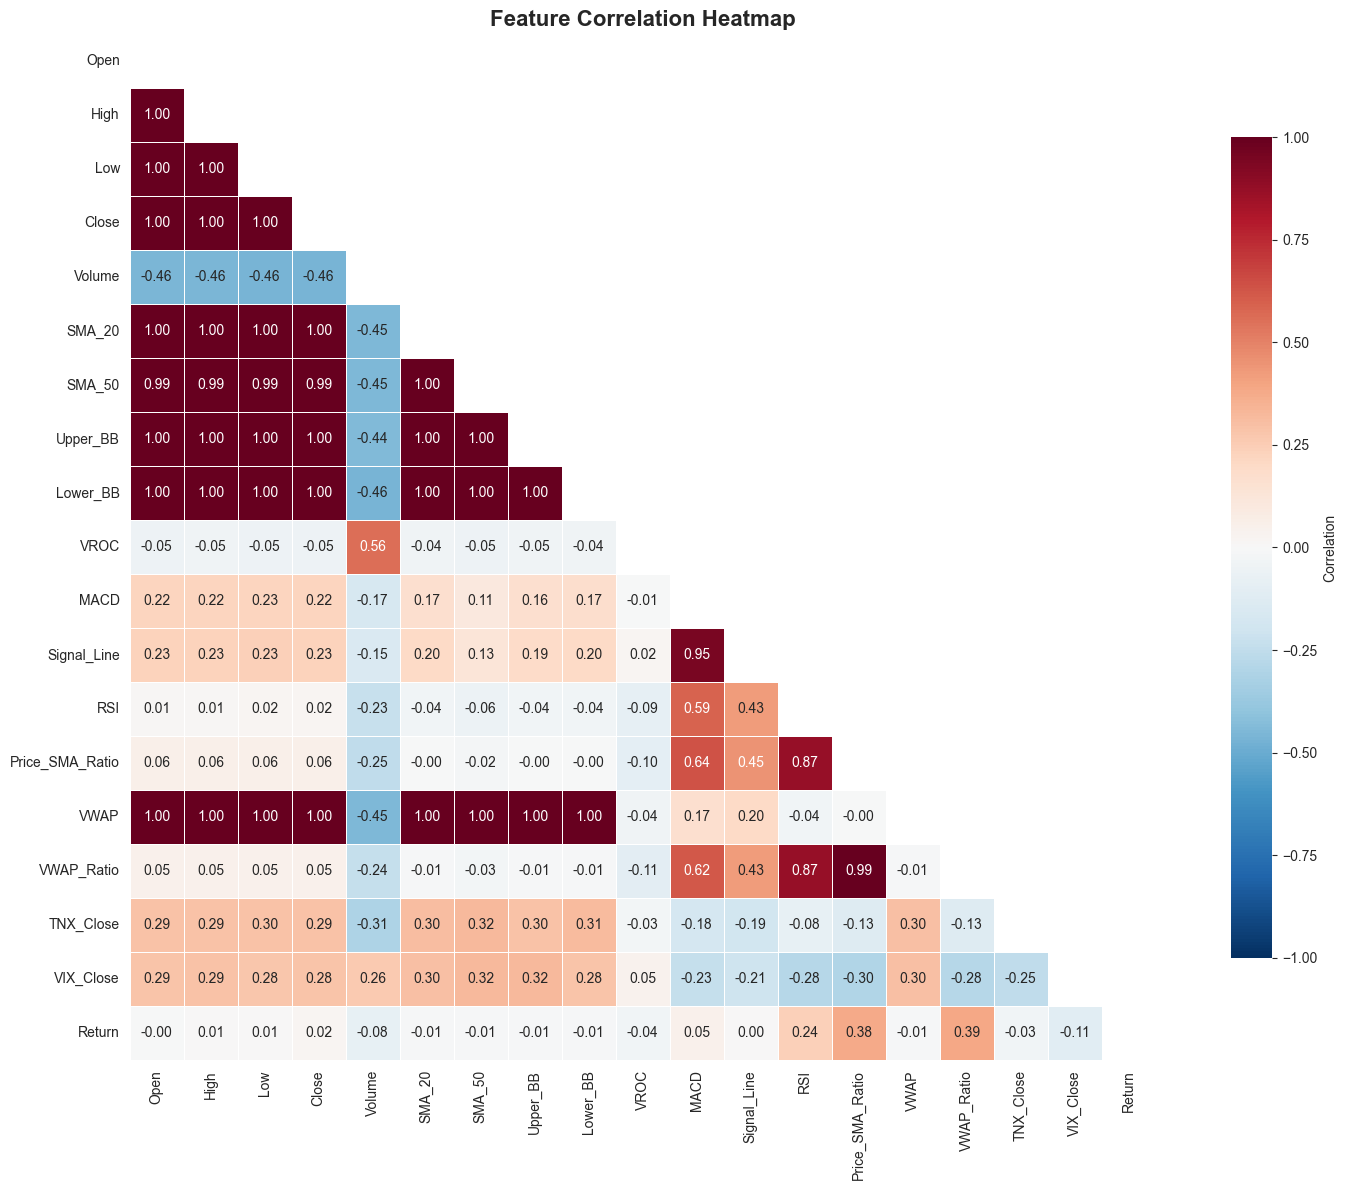


Highly Correlated Feature Pairs (|r| > 0.8):
  Open                 <-> High                  r = 1.000
  Open                 <-> Low                   r = 1.000
  Open                 <-> Close                 r = 1.000
  Open                 <-> SMA_20                r = 0.997
  Open                 <-> SMA_50                r = 0.993
  Open                 <-> Upper_BB              r = 0.997
  Open                 <-> Lower_BB              r = 0.996
  Open                 <-> VWAP                  r = 0.998
  High                 <-> Low                   r = 1.000
  High                 <-> Close                 r = 1.000
  High                 <-> SMA_20                r = 0.998
  High                 <-> SMA_50                r = 0.993
  High                 <-> Upper_BB              r = 0.997
  High                 <-> Lower_BB              r = 0.996
  High                 <-> VWAP                  r = 0.998
  Low                  <-> Close                 r = 1.000
  Low     

In [29]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50',
             'Upper_BB', 'Lower_BB', 'VROC', 'MACD', 'Signal_Line', 'RSI',
             'Price_SMA_Ratio', 'VWAP', 'VWAP_Ratio', 'TNX_Close', 'VIX_Close', 'Return']
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print highly correlated pairs (|r| > 0.8)
print("\nHighly Correlated Feature Pairs (|r| > 0.8):")
print("=" * 50)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"  {corr_matrix.columns[i]:20s} <-> {corr_matrix.columns[j]:20s}  r = {corr_matrix.iloc[i, j]:.3f}")

## 4. Hyperparameter Tuning & Preprocessing
We will define a utility function to preprocess data for different `lookback` windows and a simple tuning loop.

In [30]:
def prepare_data(df, lookback, features, target_col):
    # Use StandardScaler for better handling of Return distributions
    scaler_f = StandardScaler()
    scaled_f = scaler_f.fit_transform(df[features].values)
    
    scaler_t = StandardScaler()
    scaled_t = scaler_t.fit_transform(df[[target_col]].values)
    
    X, y = [], []
    for i in range(lookback, len(scaled_f)):
        X.append(scaled_f[i-lookback:i, :])
        y.append(scaled_t[i, 0])
        
    X, y = np.array(X), np.array(y)
    split = int(len(X) * 0.8)
    return X[:split], X[split:], y[:split], y[split:], scaler_f, scaler_t

def build_model(input_shape, model_type='LSTM'):
    # --- Functional API with Self-Attention ---
    inputs = Input(shape=input_shape)
    
    if model_type == 'LSTM':
        x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
        x = Dropout(0.2)(x)
        x = LSTM(32, return_sequences=True)(x)
    else:
        x = Bidirectional(GRU(64, return_sequences=True))(inputs)
        x = Dropout(0.2)(x)
        x = GRU(32, return_sequences=True)(x)
    
    # Attention Mechanism: learn which timesteps matter most
    attn_scores = Dense(1, activation='tanh')(x)          # (batch, timesteps, 1)
    attn_scores = Flatten()(attn_scores)                  # (batch, timesteps)
    attn_weights = Activation('softmax',
                              name='attn_w')(attn_scores) # (batch, timesteps)
    
    # Apply attention: weighted sum of hidden states
    attn_expanded = RepeatVector(32)(attn_weights)        # (batch, 32, timesteps)
    attn_expanded = Permute([2, 1])(attn_expanded)        # (batch, timesteps, 32)
    context = Multiply()([x, attn_expanded])              # (batch, timesteps, 32)
    context = Lambda(lambda z: tf.reduce_sum(z, axis=1))(context)  # (batch, 32)
    
    x = Dropout(0.2)(context)
    output = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')
    return model

features_list = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'Upper_BB', 'Lower_BB', 'VROC', 'MACD', 'Signal_Line', 'RSI', 'Price_SMA_Ratio', 'VWAP', 'VWAP_Ratio', 'TNX_Close', 'TNX_Return', 'VIX_Close', 'VIX_Return', 'Return']

### Simple Hyperparameter Tuning: Exploring Lookback Windows
We will test lookback windows of 30 vs 60 days to find the best balance.

In [31]:
results = {}
lookbacks_to_test = [10, 20, 30]

for lb in lookbacks_to_test:
    print(f"\n--- Testing Lookback: {lb} days ---")
    X_train, X_test, y_train, y_test, _, scaler_t = prepare_data(df, lb, features_list, 'Return')
    
    model = build_model((X_train.shape[1], X_train.shape[2]), 'LSTM')
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0, callbacks=[early_stop])
    
    # Calculate simple validation loss
    val_loss = min(history.history['val_loss'])
    results[lb] = val_loss
    print(f"Best Validation Loss for {lb} days: {val_loss:.4f}")

best_lookback = min(results, key=results.get)
print(f"\nBest Lookback Window Identified: {best_lookback} days")



--- Testing Lookback: 10 days ---
Best Validation Loss for 10 days: 0.3299

--- Testing Lookback: 20 days ---
Best Validation Loss for 20 days: 0.3247

--- Testing Lookback: 30 days ---
Best Validation Loss for 30 days: 0.3284

Best Lookback Window Identified: 20 days


## 5. Final Model Training (Optimized)
We train our final LSTM and GRU versions using the `best_lookback` discovered above.

In [32]:
# Prepare Final Data
X_train, X_test, y_train, y_test, scaler_f, scaler_t = prepare_data(df, best_lookback, features_list, 'Return')

# Store prices for reconstruction
actual_prices_test = df['Close'].values[best_lookback + int(len(df[best_lookback:])*0.8):]
prev_prices_test = df['Close'].values[best_lookback + int(len(df[best_lookback:])*0.8) - 1 : -1]

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

print("Training Final Optimized LSTM...")
model_lstm = build_model((X_train.shape[1], X_train.shape[2]), 'LSTM')
history_lstm = model_lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1, callbacks=callbacks)

print("\nTraining Final Optimized GRU...")
model_gru = build_model((X_train.shape[1], X_train.shape[2]), 'GRU')
history_gru = model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1, callbacks=callbacks)


Training Final Optimized LSTM...
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.3614 - val_loss: 0.3307 - learning_rate: 5.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3801 - val_loss: 0.3300 - learning_rate: 5.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3778 - val_loss: 0.3313 - learning_rate: 5.0000e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3582 - val_loss: 0.3294 - learning_rate: 5.0000e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3558 - val_loss: 0.3267 - learning_rate: 5.0000e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3839 - val_loss: 0.3432 - learning_rate: 5.0000e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3573 - val_loss: 0.3273 - learning_rate: 5.0000e-04
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.3684 - val_loss: 0.3271 - learning_rate: 5.0000e-04
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - l

## 6. Evaluation & Visualization
Reconstructing absolute prices and checking directional metrics on the test set.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


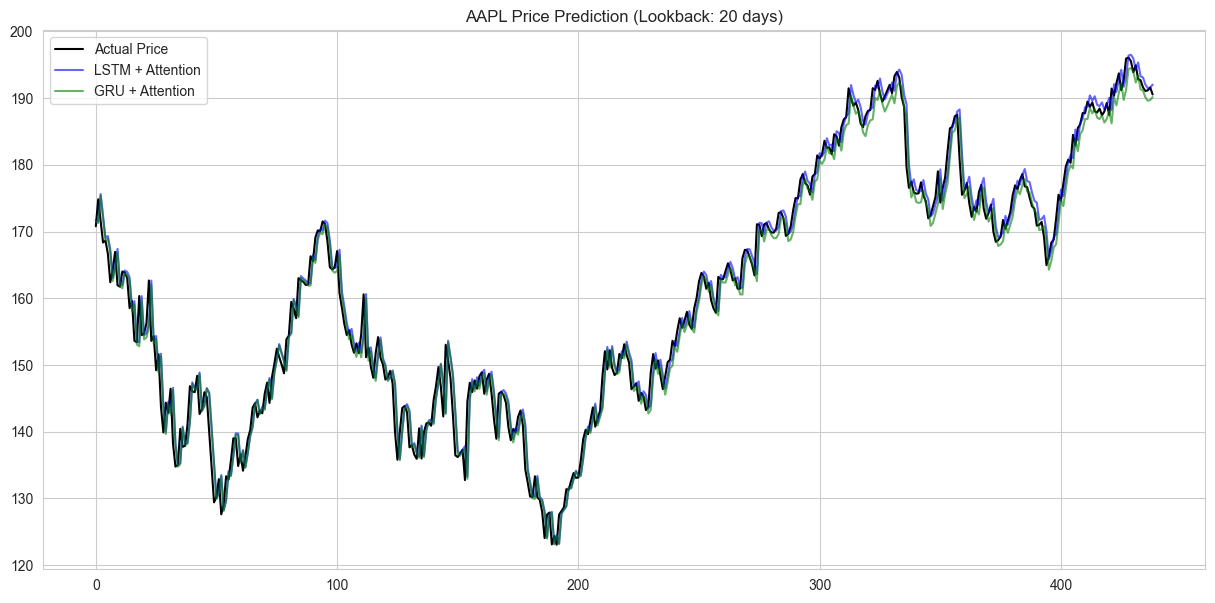

[LSTM] RMSE: 2.79 | Acc: 52.16% | F1: 0.6789
[GRU] RMSE: 2.85 | Acc: 51.94% | F1: 0.3884


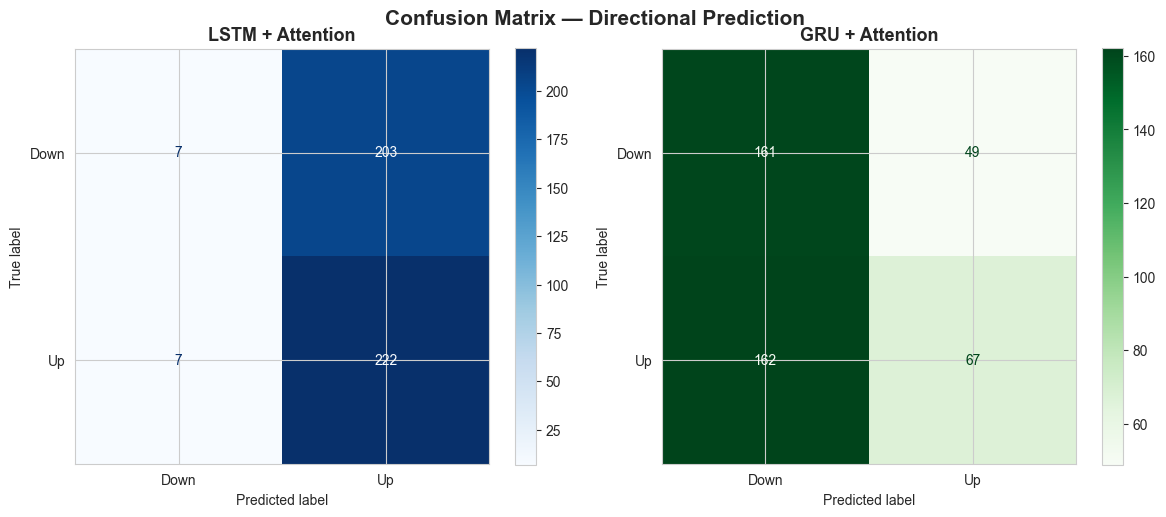

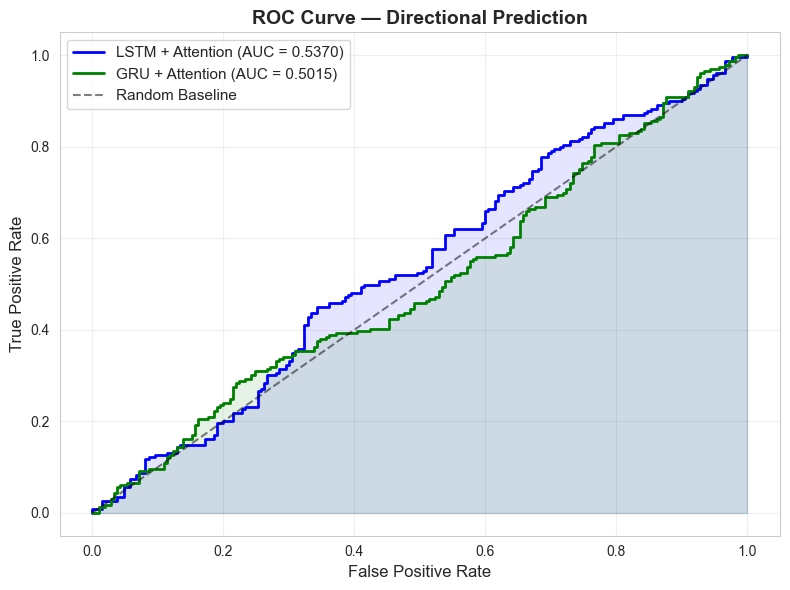

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


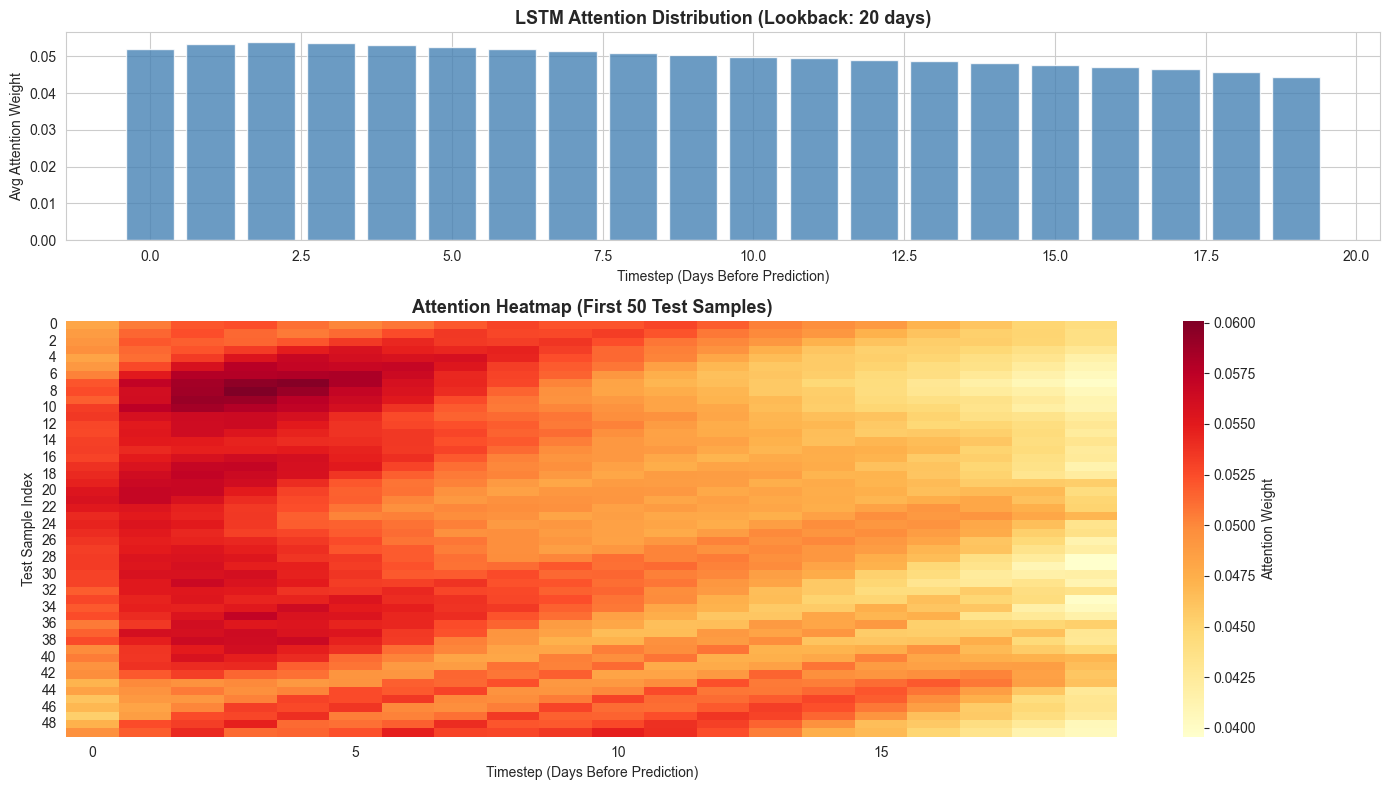

In [33]:
# Predictions (Returns)
pred_lstm_ret = scaler_t.inverse_transform(model_lstm.predict(X_test)).flatten()
pred_gru_ret = scaler_t.inverse_transform(model_gru.predict(X_test)).flatten()
y_test_ret = scaler_t.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Price Reconstruction
pred_lstm_price = prev_prices_test * (1 + pred_lstm_ret)
pred_gru_price = prev_prices_test * (1 + pred_gru_ret)

# ========================================
# 1. Price Prediction Plot
# ========================================
plt.figure(figsize=(15, 7))
plt.plot(actual_prices_test, label='Actual Price', color='black', linewidth=1.5)
plt.plot(pred_lstm_price, label='LSTM + Attention', color='blue', alpha=0.6)
plt.plot(pred_gru_price, label='GRU + Attention', color='green', alpha=0.6)
plt.title(f'AAPL Price Prediction (Lookback: {best_lookback} days)')
plt.legend()
plt.show()

# Directional Classification
actual_dir = (y_test_ret > 0).astype(int)
pred_lstm_dir = (pred_lstm_ret > 0).astype(int)
pred_gru_dir = (pred_gru_ret > 0).astype(int)

# ========================================
# 2. Metrics Summary
# ========================================
def get_metrics(model_name, actual_p, pred_p, actual_r, pred_r):
    rmse = np.sqrt(mean_squared_error(actual_p, pred_p))
    actual_d = (actual_r > 0).astype(int)
    pred_d = (pred_r > 0).astype(int)
    acc = accuracy_score(actual_d, pred_d)
    f1 = f1_score(actual_d, pred_d, zero_division=0)
    print(f"[{model_name}] RMSE: {rmse:.2f} | Acc: {acc*100:.2f}% | F1: {f1:.4f}")

get_metrics("LSTM", actual_prices_test, pred_lstm_price, y_test_ret, pred_lstm_ret)
get_metrics("GRU", actual_prices_test, pred_gru_price, y_test_ret, pred_gru_ret)

# ========================================
# 3. Confusion Matrices
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    actual_dir, pred_lstm_dir,
    display_labels=['Down', 'Up'], ax=axes[0], cmap='Blues')
axes[0].set_title('LSTM + Attention', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    actual_dir, pred_gru_dir,
    display_labels=['Down', 'Up'], ax=axes[1], cmap='Greens')
axes[1].set_title('GRU + Attention', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix \u2014 Directional Prediction',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ========================================
# 4. ROC Curve
# ========================================
fpr_lstm, tpr_lstm, _ = roc_curve(actual_dir, pred_lstm_ret)
auc_lstm = auc(fpr_lstm, tpr_lstm)
fpr_gru, tpr_gru, _ = roc_curve(actual_dir, pred_gru_ret)
auc_gru = auc(fpr_gru, tpr_gru)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lstm, tpr_lstm, color='blue', linewidth=2,
         label=f'LSTM + Attention (AUC = {auc_lstm:.4f})')
plt.plot(fpr_gru, tpr_gru, color='green', linewidth=2,
         label=f'GRU + Attention (AUC = {auc_gru:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
plt.fill_between(fpr_lstm, tpr_lstm, alpha=0.1, color='blue')
plt.fill_between(fpr_gru, tpr_gru, alpha=0.1, color='green')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve \u2014 Directional Prediction',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ========================================
# 5. Attention Heatmap (LSTM)
# ========================================
# Extract attention weights
attn_layer = [l for l in model_lstm.layers if 'attn_w' in l.name][0]
attn_model = Model(inputs=model_lstm.input, outputs=attn_layer.output)
attn_weights = attn_model.predict(X_test)

# Average attention across all test samples
avg_attn = attn_weights.mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                         gridspec_kw={'height_ratios': [1, 2]})

# Bar chart: average attention per timestep
axes[0].bar(range(len(avg_attn)), avg_attn, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Timestep (Days Before Prediction)')
axes[0].set_ylabel('Avg Attention Weight')
axes[0].set_title(f'LSTM Attention Distribution (Lookback: {best_lookback} days)',
                  fontsize=13, fontweight='bold')

# Heatmap: attention for first N test samples
sample_n = min(50, len(attn_weights))
sns.heatmap(attn_weights[:sample_n], cmap='YlOrRd', ax=axes[1],
            xticklabels=5, cbar_kws={'label': 'Attention Weight'})
axes[1].set_xlabel('Timestep (Days Before Prediction)')
axes[1].set_ylabel('Test Sample Index')
axes[1].set_title(f'Attention Heatmap (First {sample_n} Test Samples)',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Trading Strategy Backtest (Financial Metrics)
We simulate a long-only trading strategy based on the model's predictions. If the model predicts 'Up' (return > 0), we buy. Otherwise, we hold cash.
We then compute:
- **Cumulative Return**: The "Equity Curve" over time.
- **Sharpe Ratio**: Risk-adjusted returns (annualized).
- **Maximum Drawdown**: The largest peak-to-trough drop in account balance.

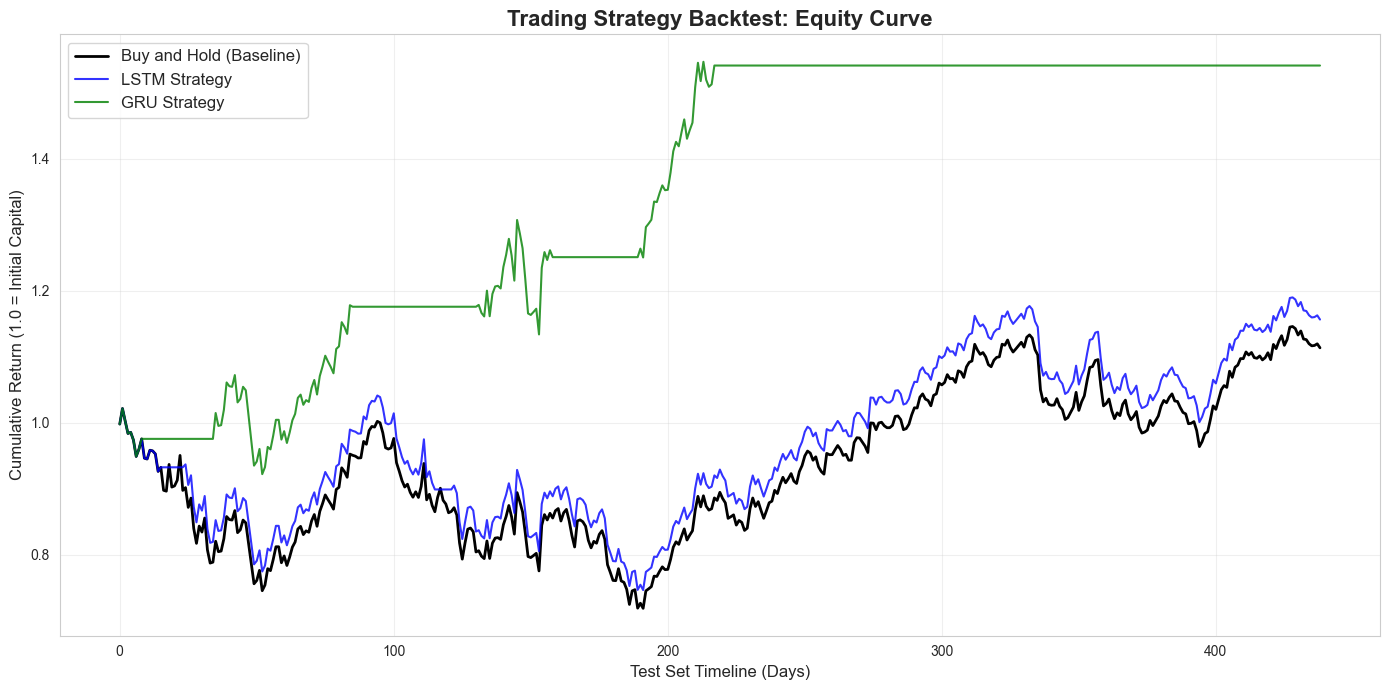

FINANCIAL PERFORMANCE METRICS
--- Buy and Hold ---
Total Return : 11.38%
Sharpe Ratio : 0.36
Max Drawdown : -29.62%

--- LSTM Strategy ---
Total Return : 15.67%
Sharpe Ratio : 0.44
Max Drawdown : -28.29%

--- GRU Strategy ---
Total Return : 54.14%
Sharpe Ratio : 1.44
Max Drawdown : -13.99%



In [34]:
# Strategy Returns (Long Only: Buy if prediction is Up)
lstm_position = (pred_lstm_ret > 0).astype(int)
gru_position = (pred_gru_ret > 0).astype(int)

# Daily returns for strategies and baseline
bnh_returns = y_test_ret
lstm_returns = lstm_position * y_test_ret
gru_returns = gru_position * y_test_ret

# Cumulative Returns
cum_bnh = np.cumprod(1 + bnh_returns)
cum_lstm = np.cumprod(1 + lstm_returns)
cum_gru = np.cumprod(1 + gru_returns)

# 1. Plot Equity Curve
plt.figure(figsize=(14, 7))
plt.plot(cum_bnh, label='Buy and Hold (Baseline)', color='black', linewidth=2)
plt.plot(cum_lstm, label='LSTM Strategy', color='blue', alpha=0.8)
plt.plot(cum_gru, label='GRU Strategy', color='green', alpha=0.8)
plt.title('Trading Strategy Backtest: Equity Curve', fontsize=16, fontweight='bold')
plt.xlabel('Test Set Timeline (Days)', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = Initial Capital)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Financial Metrics calculation function
def calc_financial_metrics(returns, cum_returns, name):
    # Sharpe Ratio (annualized, assuming 252 trading days)
    # Mean daily return / daily standard deviation
    sharpe = np.sqrt(252) * (np.mean(returns) / (np.std(returns) + 1e-8))
    
    # Maximum Drawdown
    rolling_max = np.maximum.accumulate(cum_returns)
    drawdowns = cum_returns / rolling_max - 1
    mdd = np.min(drawdowns)
    
    # Total Return
    total_ret = cum_returns[-1] - 1
    
    print(f"--- {name} ---")
    print(f"Total Return : {total_ret*100:.2f}%")
    print(f"Sharpe Ratio : {sharpe:.2f}")
    print(f"Max Drawdown : {mdd*100:.2f}%\n")

print("FINANCIAL PERFORMANCE METRICS\n" + "="*30)
calc_financial_metrics(bnh_returns, cum_bnh, "Buy and Hold")
calc_financial_metrics(lstm_returns, cum_lstm, "LSTM Strategy")
calc_financial_metrics(gru_returns, cum_gru, "GRU Strategy")